# Section 1: Importing our Modules, Packages, API Base, and API Key
### This section loads the main modules we used for the project and suppresses specific warnings. 

In [13]:
import os 
import litellm 
import json 
import warnings 
from dotenv import load_dotenv 
import numpy as np
import matplotlib.pyplot as plt 
import requests
import networkx as nx  

# Above, we imported all of the necessary modules we used in the creation of our project. 

# Load environment variables
load_dotenv()

# Suppresses specific Pydantic warnings
warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

custom_api_base = "https://litellmproxy.osu-ai.org" 
astro1221_key = os.getenv("ASTRO1221_API_KEY") 
# Here, we created variables for the API base and the API key. 
# Helpful Source: Class 9: Section 1

# Section 2: Conversation Prompt: Character Descriptions, Discussion, and Flow of Conversation
### This section includes the prompt we use to generate the conversation amongst our three characters, along with their personality traits and the flow of the discussion. 

##### In this section, the primary issue we encountered surrounded the details of the character descriptions and maintaining the flow of the conversation. Without providing detailed descriptions of each character's personality, along with including specifications on exactly how the characters are supposed to speak/interact with one another, the LLM struggled to remain consistent in the response output. Ultimately, we resolved this issue by prompting "human-like" traits, such as "enthusiastic" or "inquisitive", and creating the "CONVERSATION FLOW" parameter within the prompt. 

In [14]:
conversation_prompt = """ 
CHARACTERS:
-Dr. Daniel Beer: an enthusiastic and inquisitive astrophysicist who studies cosmology, including dark matter
and dark energy, galactic evolution and quasars, and the intergalactic medium (IGM).

-Dr. Davis Milk: a curious and passionate astrophysicist who studies supermassive black holes.

-Dr. Phil Marg: an excited and speculative astrophyscist that studies
cosmology, specifically galactic evolution and active galactic nuclei (AGN).

DISCUSSION:
Have the characters have a debate about the paper THE ORIGIN OF DUST IN EARLY-TYPE GALAXIES 
AND IMPLICATIONS FOR ACCRETION ONTO SUPERMASSIVE BLACK HOLES 
Paul Martini 1,4,  Daniel Dicken 2, and Thaisa Storchi-Bergmann. 

CONVERSATION FLOW: 
Have the characters talk in random order amongst each other as if they are humans having an ordinary debate. 
They do not have to talk in the order in which the characters are listed 
- For example, the order can be: "Dr. Phil Marg" to "Dr. Davis Milk" to "Dr. Phil Marg" to "Dr. Daniel Milk". 
Make the conversation natural. 
."""

#  The variable above contains the discussion prompt, character personalities, and the flow of the conversation. 
#  We included emphasis on the natural aspect of the discussion to make the LLM sound more "human-like".
#  The title of the paper below is a secondary example of a paper for the characters to discuss.

#  (Resolved H II Regions in NGC 253: Ionized Gas Structure and Suggestions of a Universal Density─Surface Brightness Relation
#  McClain, Rebecca L. search by orcid ; Leroy, Adam K. search by orcid ; Congiu, Enrico search by orcid) 

# Helpful Source: Class 9: Section 4
# Helpful Source: https://pub.towardsai.net/simulating-conversations-with-chatgpt-fd7f34aebb0c

# Section 3: LLM Prompt Function
### This section includes the specifics of our function used to call the LLM.

In [16]:
def prompt_llm(messages, model="openai/GPT-4.1-mini", temperature=0.5, max_tokens=1000, tools=None, verbose=True):
    """   
    Send a prompt or conversation to an LLM using LiteLLM and return the response.
    """ # The prompt_llm() defines a function for creating an LLM prompt. 
        # The temperature is set to 0.5 to emperature is set to 0.5 to 
        # ensure consistency amongst character responses, and the maximum 
        # number of tokens is set to 1000 to ensure in-depth responses from the characters. 
    if isinstance(messages, str):
        messages = [{"role": "user", "content": conversation_prompt}] 
        # The messages variable creates a dictionary for the LLM response (role is user, content is the generated 
        # message from the conversation prompt (ONLY IF IT IS A STRING)).
       
    if not (isinstance(temperature, (int, float)) and 0 <= temperature <= 2): 
        raise ValueError("temperature must be a float between 0 and 2 (inclusive).") 
        # raises an error if temperature is less than 0 or greater than 2, as temperature must be within (0,2).
    if not (isinstance(max_tokens, int) and max_tokens > 0):
        raise ValueError("max_tokens must be a positive integer.")
        # raises an error if the max_tokens amount is less than zero.
   
    try: 
        print("Contacting LLM via University Server...")
        conversation_response = litellm.completion(
            model=model,
            messages=messages,
            tools=tools,
            api_base=custom_api_base,
            api_key=astro1221_key,
            temperature=temperature,
            max_tokens=max_tokens, 
        ) # The try block contacts the LLM server through litellm.completion function to get a response 
          # using the model, message (our prompt), api base, and key, 
          # and the temperature and tokens we established above.
           
        conversation_answer = conversation_response['choices'][0]['message']['content'] 
        if verbose: 
            print(f"\nSUCCESS! Here is the discussion from {model}:\n")
            print(conversation_answer + "\n")
            print(f"{conversation_answer['name']}: {conversation_answer['reply']}")
            conversation_history += f"{conversation_answer['name']}: {conversation_answer['reply']}\n"
         # The conversation_answer represents the AI's answer from the conversation_response function, 
         # and if there's enough info generated from the conversation response (verbose), it prints the conversation 
         # in the format of 'name': reply, with 'name' being the character's name, and reply being their response to
         # to the conversation. 
    
    except Exception as e:
        print(f"\nERROR: Could not connect. Details:\n{e}")    
        conversation_response = None 
        # Prints "Could not connect" and does not generate a response if an error is encountered.
    
    return conversation_response 

  # Helpful Source: Class 9 Section 1 

# Section 4: LLM Memory Function
### This section includes our function that saves the LLM's discussion output. 

In [17]:
def conversation_with_history(user_input):
     # This function, overall, saves content from the conversation prompt response into the conversation_history variable.
    conversation_history = [{"role": "user", "content": conversation_prompt}]  
    conversation_history.append({"role": "user", "content": user_input})
    response = prompt_llm(conversation_history) 
    if response is None:
        return None
    ai_answer = response.choices[0].message.content

    conversation_history.append({"role": "system", "content": ai_answer})
    # This line above is important: conversation_history.append adds the AI's own answer to memory so it remembers what it said.

    return ai_answer
# Helpful source: Class 9 Section 5

# Section 5: Discussion Output and Tracking Interactions 
### In this section, we generate the conversation amongst the three characters and use a separate prompt to keep track of how many times the different characters directly interact with one another. 

In [18]:
prompt_llm(conversation_prompt)
print('=' * 60) # Spacing for organization

conversation_summary_prompt = "Make an organized list to show which characters interacted with each other and how many times they did."
# This is the prompt that tells the LLM to make a list of who each character communicated with, 
# and how many times they did so when called into the conversation_with_history function.

print(f"\nAsking about question original conversation: {conversation_summary_prompt}")
print(conversation_with_history(conversation_summary_prompt)) 
# AI/LLM remembers what three characters talked about. 

# Helpful Source: Class 9 Section 5

Contacting LLM via University Server...

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


ERROR: Could not connect. Details:
litellm.AuthenticationError: AuthenticationError: OpenAIException - The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable

Asking about question original conversation: Make an organized list to show which characters interacted with each other and how many times they did.
Contacting LLM via University Server...

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


ERROR: Could not connect. Details:
litellm.AuthenticationError: AuthenticationError: OpenAIException - The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment v

# Section 6: Creating a CSV File to Track the Number of Interactions Between Each Character

In [6]:

import csv
# Below is the dictionary we used to create the CSV file. We manually change the 
# number of times each character interacts with another, as it changes every time the code is 
# rerun and a new conversation is generated. 
response_data = [
      {'Source': 'Dr. Daniel Beer', 'Target': 'Dr. Davis Milk', 'Interaction Count': 2}, 
      {'Source': 'Dr. Davis Milk', 'Target': 'Dr. Phil Marg',   'Interaction Count': 3},
      {'Source': 'Dr. Phil Marg', 'Target': 'Dr. Daniel Beer',  'Interaction Count': 2}
]
with open('response_data.csv', 'w', newline='') as file: # 'w' is write 
    fieldnames = ['Source', 'Target', 'Interaction Count']
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    # fieldnames defines our headers: Source, Target, and Interaction Count
    writer.writeheader() # writes the headers
    writer.writerows(response_data) # writes the rows 
    
print("Created response_data.csv") 
# Write data rows
with open('response_data.csv', mode='r') as file: # 'r' is read 
    reader = csv.DictReader(file) 
    print(f"{'Source'}           | {'Target'}             |  {'Interaction Count'}")
    print("=" * 50)
    
    for row in reader: # This loop updates the CSV every time we manually change the interaction count. 
        source = row['Source']
        target = row['Target']
        interaction_count = float(row['Interaction Count'])
        
        print(f"{source}    |   {target} |       {interaction_count}")

# Helpful Source: Class 4: Section 6

Created response_data.csv
Source           | Target             |  Interaction Count
Dr. Daniel Beer    |   Dr. Davis Milk |       2.0
Dr. Davis Milk    |   Dr. Phil Marg |       3.0
Dr. Phil Marg    |   Dr. Daniel Beer |       2.0


# Section 7: Using Pandas to Read our Response Data CSV File and Create our Network Diagram for Interactions Between Characters 
#### In this section, our primary struggle was maintaining the position of the labels when graphing our network diagram. Every time we ran the code, the position of the labels showing the interaction count would change. We corrected this issue by creating a seed to hold the positions. 

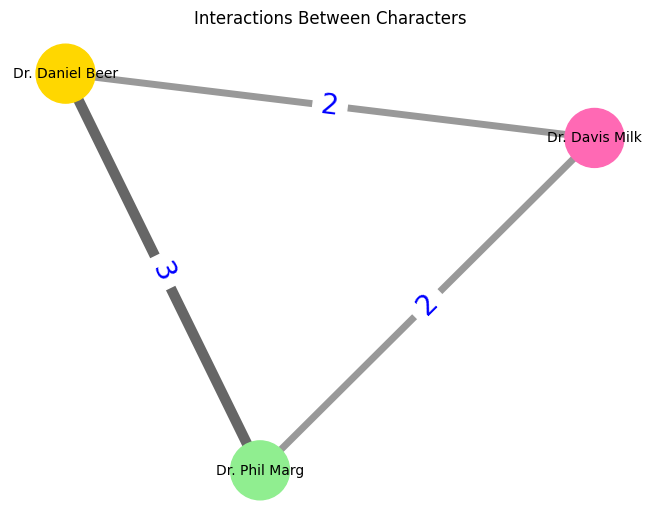

In [16]:
import pandas as pd

df = pd.read_csv("response_data.csv") # Here, we used the pandas function pd.read_csv to read our CSV file into a data frame.
df
G= nx.from_pandas_edgelist(df, "Source", "Target") # Because the CSV was read into a data frame, 
                                                   # we were able to use the nx.from_pandas_edgelist function to 
                                                   # create a network diagram connecting the "Sources" to the "Targets" 
                                                   # (the names of each character). 
seed = 31 
np.random.seed(seed)
pos = nx.spring_layout(G, seed=seed) # This ensures each produced graph has the same layout (each node will remain 
                                     # in the same position) to prevent incorrect labeling.


# Below, we use the variables "width" and "alpha" to make the labels of the graph change opacity and width based on 
# the number of interactions a character has. The more interactions a character has, the wider and more opaque the labels are.  

interactions = df['Interaction Count'].tolist()
width = [x * 2.5 for x in interactions]
alpha = [x / 5 for x in interactions]

nodelist = [('Dr. Daniel Beer'), ('Dr. Davis Milk'), ('Dr. Phil Marg')]

# Below, in the dictionary edge_labels, we manually input the interaction count, as the 
# number of times each character interacts with another changes each time we run the program. 

node_color = ['gold', 'hotpink', 'lightgreen']
edge_labels = {('Dr. Daniel Beer', 'Dr. Davis Milk'): interactions[0], 
                ('Dr. Davis Milk', 'Dr. Phil Marg'): interactions[2],
                ('Dr. Phil Marg', 'Dr. Daniel Beer'):  interactions[1]}


# Below, we use the nx functions to draw the labels, establish the font size for the text, and 
# adjust the color, size, width, and opacity for the nodes and labels based on the
# variables node_color and edge_labels established above. 

nx.draw(G, with_labels=True, font_size=10, node_size=1800, node_color=node_color, width=width, edge_color='white')
nx.draw_networkx_edges(G, pos, alpha=alpha, width=width) 
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='blue', font_size=20)


plt.title('Interactions Between Characters')
plt.axis("off")
plt.show() 


# Helpful Sources: Lecture 11 and the article "Graphing Network Data with Pandas" (https://pandas.pythonhumanities.com/04_02_graphing_networks_with_pandas.html) 